In [1]:
import tensorflow as tf
tf.keras.backend.clear_session()

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import models, transforms
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import random

In [3]:
import tensorflow as tf

# Check if GPU is available
if tf.config.list_physical_devices('GPU'):
    print("Using GPU")
else:
    print("Using CPU")

print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

Using GPU
Num GPUs Available:  1


In [4]:
disease_types = ['Cirrhosis','Periportal Fibrosis','Portal Fibrosis','Septal Fibrosis','No Fibrosis']
data_dir = '/content/Resized_Dataset'

train_data = []
for defects_id, sp in enumerate(disease_types):
    for file in os.listdir(os.path.join(data_dir, sp)):
        train_data.append(['{}/{}'.format(sp, file), defects_id, sp])
train = pd.DataFrame(train_data, columns=['File', 'DiseaseID','Disease Type'])

In [5]:
class FibrosisDataset(Dataset):
    def __init__(self, dataframe, data_dir, transform=None):
        self.dataframe = dataframe
        self.data_dir = data_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = os.path.join(self.data_dir, self.dataframe.iloc[idx, 0])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        label = self.dataframe.iloc[idx, 1]

        if self.transform:
            image = self.transform(image)
        return image, label

In [6]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [7]:
dataset = FibrosisDataset(train, data_dir, transform=transform)
total_size = len(dataset)
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [8]:
print(test_size)

635


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, len(disease_types))

for param in model.parameters():
    param.requires_grad = True

# # Unfreeze only the last 10 parameter tensors
# for param in list(model.parameters())[-10:]:
#     param.requires_grad = True

model = model.to(device)

# Define loss, optimizer, scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)


In [10]:
epochs = 50
train_losses, val_losses, val_accs = [], [], []
best_val_acc = 0.0
patience = 10
trigger_times = 0

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct / total
    scheduler.step()

    print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        trigger_times = 0
        # torch.save(model.state_dict(), 'best_model.pth')
        print(f"Saved best model at epoch {epoch+1}; best_val_acc: {best_val_acc}")
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

Epoch [1/50], Train Loss: 0.6521, Val Loss: 0.5344, Val Acc: 79.50%
Saved best model at epoch 1; best_val_acc: 79.49526813880126
Epoch [2/50], Train Loss: 0.3560, Val Loss: 0.5772, Val Acc: 78.23%
Epoch [3/50], Train Loss: 0.2477, Val Loss: 0.4120, Val Acc: 85.49%
Saved best model at epoch 3; best_val_acc: 85.48895899053628
Epoch [4/50], Train Loss: 0.1534, Val Loss: 0.1994, Val Acc: 92.27%
Saved best model at epoch 4; best_val_acc: 92.27129337539432
Epoch [5/50], Train Loss: 0.1162, Val Loss: 0.3230, Val Acc: 89.12%
Epoch [6/50], Train Loss: 0.0967, Val Loss: 0.2231, Val Acc: 93.38%
Saved best model at epoch 6; best_val_acc: 93.37539432176656
Epoch [7/50], Train Loss: 0.0826, Val Loss: 0.1849, Val Acc: 93.85%
Saved best model at epoch 7; best_val_acc: 93.84858044164038
Epoch [8/50], Train Loss: 0.0666, Val Loss: 0.1242, Val Acc: 95.90%
Saved best model at epoch 8; best_val_acc: 95.89905362776025
Epoch [9/50], Train Loss: 0.1033, Val Loss: 0.0858, Val Acc: 97.16%
Saved best model at ep

In [11]:
model.eval()
y_true, y_pred, y_prob = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        probs = torch.softmax(outputs, dim=1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())


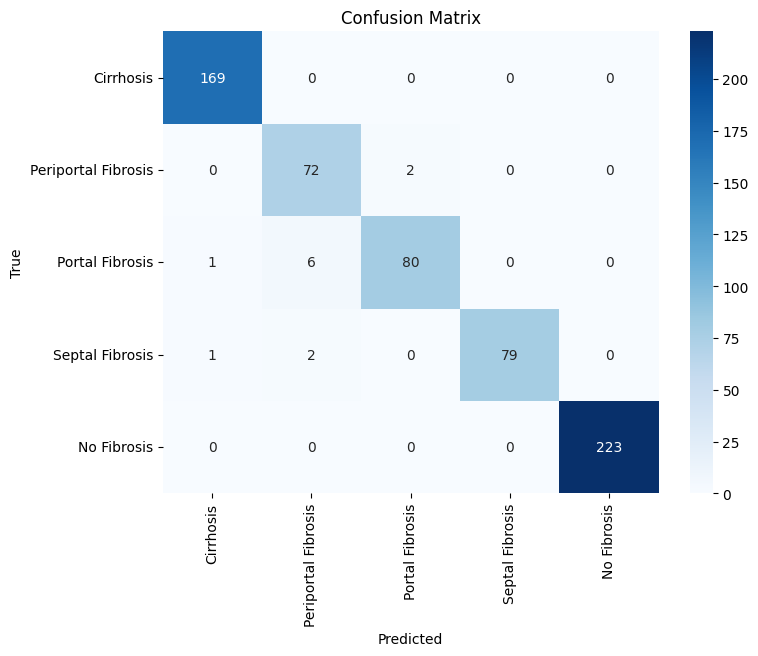

In [12]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=disease_types, yticklabels=disease_types)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [13]:
print("Classification Report:\n", classification_report(y_true, y_pred, target_names=disease_types))

Classification Report:
                      precision    recall  f1-score   support

          Cirrhosis       0.99      1.00      0.99       169
Periportal Fibrosis       0.90      0.97      0.94        74
    Portal Fibrosis       0.98      0.92      0.95        87
    Septal Fibrosis       1.00      0.96      0.98        82
        No Fibrosis       1.00      1.00      1.00       223

           accuracy                           0.98       635
          macro avg       0.97      0.97      0.97       635
       weighted avg       0.98      0.98      0.98       635



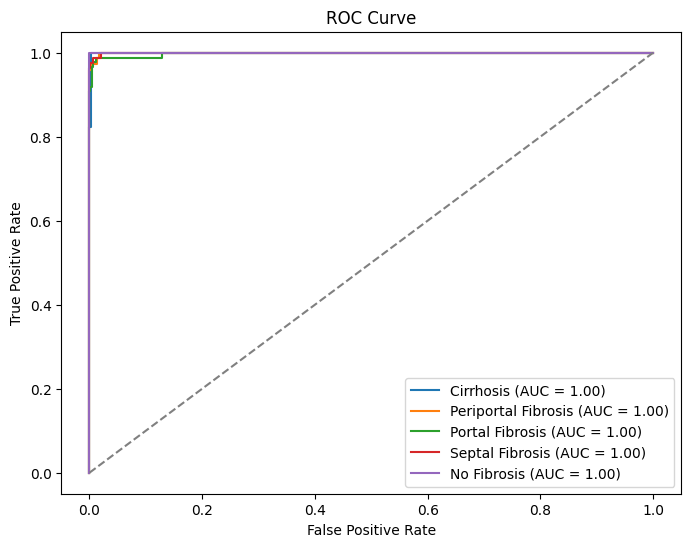

In [14]:
# ROC AUC
fpr, tpr, roc_auc = {}, {}, {}
y_true_onehot = np.eye(len(disease_types))[y_true]
y_prob = np.array(y_prob)

for i in range(len(disease_types)):
    fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], y_prob[:, i])
    roc_auc[i] = roc_auc_score(y_true_onehot[:, i], y_prob[:, i])

plt.figure(figsize=(8,6))
for i in range(len(disease_types)):
    plt.plot(fpr[i], tpr[i], label=f"{disease_types[i]} (AUC = {roc_auc[i]:.2f})")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

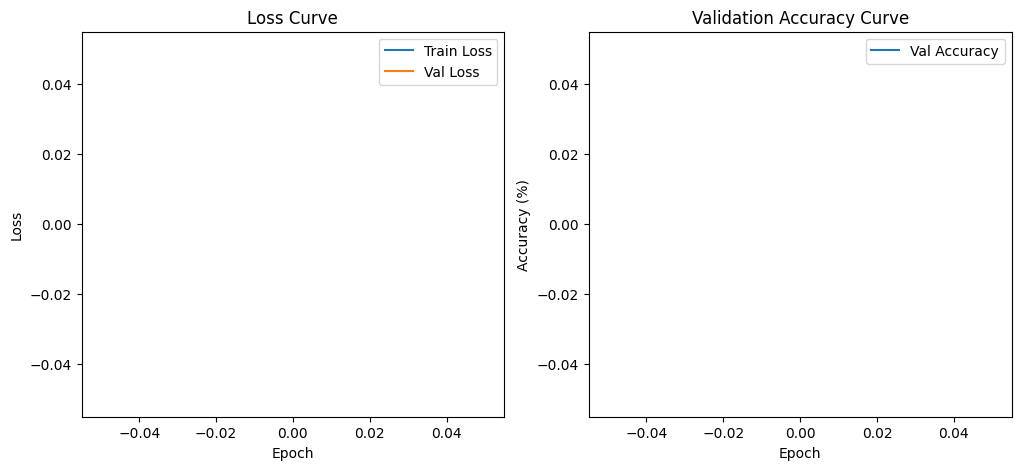

In [15]:
# Loss & Accuracy Curves
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(val_accs, label='Val Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Validation Accuracy Curve")
plt.legend()
plt.show()


In [16]:
# torch.save(model, "/kaggle/working/efficienetb0_baseline_10_layer_trainable.pth")